# 评论类别聚类分析

**目标**：用数据驱动的聚类方法（TF-IDF + UMAP + HDBSCAN）替代人工指定的 14 个类别，并解决一条评论归属多个类别的多标签问题。

**流程**：
1. 加载数据，解析现有人工类别
2. TF-IDF 向量化评论文本
3. UMAP 降维
4. HDBSCAN 聚类（自动确定类别数）
5. 多标签分配（每条评论可属于多个主题）
6. 聚类结果与人工类别对比分析
7. 用 LLM 为每个聚类生成语义标签和摘要
8. 导出带多标签的新 CSV 和 category_summaries_cluster.json

## 0. 安装 & 导入

In [28]:
# 确认依赖
import importlib, sys
for pkg in ['umap', 'hdbscan', 'sklearn', 'jieba']:
    try:
        importlib.import_module(pkg)
        print(f'✓ {pkg}')
    except ImportError:
        print(f'✗ {pkg} — 请先运行: pip install {pkg}')

✓ umap
✓ hdbscan
✓ sklearn
✓ jieba


In [29]:
import os, ast, re, json
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
from pathlib import Path

import jieba
import umap
import hdbscan
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 中文字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# DashScope API（用于后续 LLM 生成摘要）
from dashscope import Generation

print('所有依赖加载成功')

所有依赖加载成功


## 1. 加载数据

In [30]:
# ── 路径配置 ──────────────────────────────────────────────────────────────────
# notebook 在 All-about-the-Hotel/ 下，数据在上两级的 data/
BASE_DIR   = Path('../../data')          # 相对路径，可按实际修改
DATA_FILE  = BASE_DIR / 'filtered_comments-syh.csv'
STOP_FILE  = BASE_DIR / 'stopwords_chinese.txt'
OUT_CSV    = BASE_DIR / 'filtered_comments_clustered.csv'
OUT_JSON   = BASE_DIR / 'category_summaries_cluster.json'
# ─────────────────────────────────────────────────────────────────────────────

df = pd.read_csv(DATA_FILE)
print(f'数据加载成功: {len(df)} 条评论，{df.shape[1]} 列')
print('列名:', df.columns.tolist())

数据加载成功: 2171 条评论，16 列
列名: ['_id', 'comment', 'images', 'score', 'publish_date', 'room_type', 'fuzzy_room_type', 'travel_type', 'comment_len', 'log_comment_len', 'useful_count', 'log_useful_count', 'review_count', 'log_review_count', 'quality_score', 'categories']


In [31]:
# 解析现有人工类别
def parse_categories(raw):
    if pd.isna(raw):
        return []
    try:
        return ast.literal_eval(str(raw))
    except:
        return [str(raw).strip()]

df['categories_list'] = df['categories'].apply(parse_categories)

# 统计人工类别分布
all_manual_cats = [c for cats in df['categories_list'] for c in cats]
manual_cnt = Counter(all_manual_cats)
print(f'人工类别数: {len(manual_cnt)}')
print('\n人工类别分布（按频次）:')
for cat, cnt in manual_cnt.most_common():
    print(f'  {cat:12s}: {cnt:4d} 条')

# 每条评论的标签数
label_counts = df['categories_list'].apply(len)
print(f'\n平均标签数: {label_counts.mean():.2f}')
print(f'标签数分布: {dict(Counter(label_counts.tolist()))}')

人工类别数: 14

人工类别分布（按频次）:
  整体满意度       : 1559 条
  前台服务        : 1242 条
  餐饮设施        :  676 条
  房间设施        :  590 条
  交通便利性       :  431 条
  卫生状况        :  351 条
  公共设施        :  268 条
  周边配套        :  235 条
  客房服务        :  234 条
  性价比         :  146 条
  安静程度        :  141 条
  退房/入住效率     :  101 条
  景观/朝向       :   82 条
  价格合理性       :   13 条

平均标签数: 2.80
标签数分布: {3: 1778, 2: 344, 1: 47, 0: 2}


## 2. 文本预处理 & TF-IDF 向量化

In [65]:
# 加载中文停用词
stopwords = set()
if STOP_FILE.exists():
    with open(STOP_FILE, encoding='utf-8') as f:
        stopwords = {line.strip() for line in f if line.strip()}
print(f'停用词加载: {len(stopwords)} 个')

# 追加常见无意义词
stopwords.update(['酒店', '广州', '花园', '花园酒店', '入住', '服务', '房间', '的', '了', '是',
                  '都', '很', '也', '在', '有', '我', '们', '这', '那', '上',
                  '就', '不', '没', '但', '还', '来', '去', '把', '给', '让'])

def tokenize(text):
    """jieba 分词 + 停用词过滤"""
    text = re.sub(r'[^\u4e00-\u9fffa-zA-Z]', ' ', str(text))
    tokens = jieba.lcut(text)
    return ' '.join(t for t in tokens if t.strip() and t not in stopwords and len(t) > 1)

print('正在分词...')
texts_tokenized = df['comment'].apply(tokenize).tolist()
print(f'分词完成，样例: {texts_tokenized[0][:80]}...')

停用词加载: 746 个
正在分词...
分词完成，样例: 非常 装修 厚重 奢华 评论 po 照片 感觉 快捷酒店 害怕 但来 之后 真的 惊喜 装修 厚重 奢华 老牌 日系 帝国 感觉 没想到 开业 时间 很长 仍然...


In [66]:
# TF-IDF 向量化
tfidf = TfidfVectorizer(
    max_features=3000,   # 保留 top-3000 词
    min_df=3,            # 至少在 3 条评论中出现
    max_df=0.85,         # 不超过 85% 评论（过于普遍的词无意义）
    sublinear_tf=True,   # 对词频取对数，缓解长文本偏差
)
X_tfidf = tfidf.fit_transform(texts_tokenized)
print(f'TF-IDF 矩阵维度: {X_tfidf.shape}  (评论数 × 特征词数)')

TF-IDF 矩阵维度: (2171, 3000)  (评论数 × 特征词数)


## 3. UMAP 降维

In [67]:
print('UMAP 降维中（首次运行约需 30-60 秒）...')

# 先降到 50 维用于 HDBSCAN（高维聚类效果差）
reducer_50 = umap.UMAP(
    n_components=50,
    n_neighbors=15,
    min_dist=0.0,        # min_dist=0 更适合聚类
    metric='cosine',
    random_state=42,
    low_memory=True,
)
X_50d = reducer_50.fit_transform(X_tfidf)

# 再降到 2 维用于可视化
reducer_2d = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=42,
    low_memory=True,
)
X_2d = reducer_2d.fit_transform(X_tfidf)

print(f'降维完成: 50 维 shape={X_50d.shape}, 2 维 shape={X_2d.shape}')

UMAP 降维中（首次运行约需 30-60 秒）...


d:\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


降维完成: 50 维 shape=(2171, 50), 2 维 shape=(2171, 2)


## 4. HDBSCAN 聚类

In [84]:
# HDBSCAN 聚类（自动确定簇数，cluster_id=-1 为噪声点）
# min_cluster_size=30, eom: 原始参数，施工噪音与自助餐厅可以分开
# 重复标签问题在 LLM 打标阶段通过 existing_labels 解决
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=30,
    min_samples=5,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True,
    gen_min_span_tree=True,
)
cluster_labels = clusterer.fit_predict(X_50d)

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise    = (cluster_labels == -1).sum()
print(f'发现 {n_clusters} 个聚类（原人工类别数：{len(manual_cnt)}）')
print(f'噪声点（无法归类）: {n_noise} 条（{n_noise/len(df)*100:.1f}%）')
print('\n各簇大小:')
for c, cnt in sorted(Counter(cluster_labels).items()):
    label = '（噪声）' if c == -1 else ''
    print(f'  簇 {c:3d}{label}: {cnt:4d} 条')


发现 14 个聚类（原人工类别数：14）
噪声点（无法归类）: 957 条（44.1%）

各簇大小:
  簇  -1（噪声）:  957 条
  簇   0:   43 条
  簇   1:   33 条
  簇   2:  152 条
  簇   3:   59 条
  簇   4:   33 条
  簇   5:   70 条
  簇   6:  192 条
  簇   7:  126 条
  簇   8:   62 条
  簇   9:   96 条
  簇  10:   84 条
  簇  11:   64 条
  簇  12:   67 条
  簇  13:  133 条


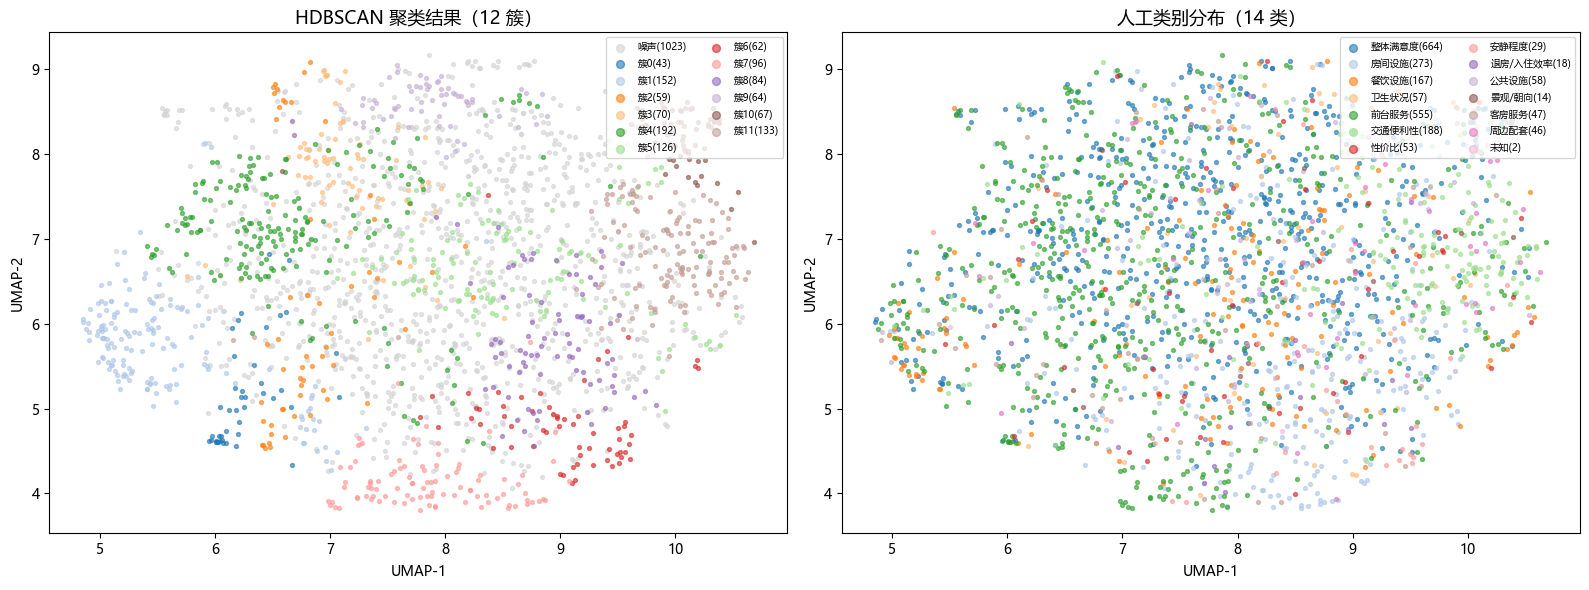

图片已保存: clustering_visualization.png


In [78]:
# 可视化：2D UMAP 散点图，按聚类上色
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左图：HDBSCAN 聚类
ax = axes[0]
palette = plt.cm.tab20.colors
for cid in sorted(set(cluster_labels)):
    mask = cluster_labels == cid
    color = 'lightgray' if cid == -1 else palette[cid % len(palette)]
    label = f'噪声({mask.sum()})' if cid == -1 else f'簇{cid}({mask.sum()})'
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=[color], s=8, alpha=0.6, label=label)
ax.set_title(f'HDBSCAN 聚类结果（{n_clusters} 簇）', fontsize=13)
ax.legend(loc='upper right', fontsize=7, markerscale=2, ncol=2)
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')

# 右图：人工类别（每条评论取第一个标签）
ax2 = axes[1]
manual_first = df['categories_list'].apply(lambda x: x[0] if x else '未知')
unique_manual = manual_first.unique()
color_map = {cat: palette[i % len(palette)] for i, cat in enumerate(unique_manual)}
for cat in unique_manual:
    mask = manual_first == cat
    ax2.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=[color_map[cat]], s=8, alpha=0.6, label=f'{cat}({mask.sum()})')
ax2.set_title(f'人工类别分布（{len(unique_manual)} 类）', fontsize=13)
ax2.legend(loc='upper right', fontsize=7, markerscale=2, ncol=2)
ax2.set_xlabel('UMAP-1'); ax2.set_ylabel('UMAP-2')

plt.tight_layout()
plt.savefig('clustering_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('图片已保存: clustering_visualization.png')

## 5. 聚类质量评估

In [79]:
# Silhouette Score（只对有聚类标签的样本计算）
mask_valid = cluster_labels != -1
if mask_valid.sum() > 1 and len(set(cluster_labels[mask_valid])) > 1:
    score = silhouette_score(
        X_50d[mask_valid],
        cluster_labels[mask_valid],
        metric='euclidean',
        sample_size=min(2000, mask_valid.sum()),  # 抽样加速
        random_state=42
    )
    print(f'Silhouette Score: {score:.4f}  （越接近 1 越好，>0.2 可接受）')
else:
    print('簇数不足，无法计算 Silhouette Score')

# DBCV（HDBSCAN 内置的密度聚类质量分数）
try:
    print(f'HDBSCAN DBCV Score: {clusterer.relative_validity_:.4f}  （越高越好）')
except AttributeError:
    print('DBCV Score: 不可用（需重新运行上方聚类单元格以生成最小生成树）')

Silhouette Score: 0.4070  （越接近 1 越好，>0.2 可接受）
HDBSCAN DBCV Score: 0.3154  （越高越好）


## 6. 每个聚类的 TF-IDF 关键词提取

In [85]:
feature_names = np.array(tfidf.get_feature_names_out())

cluster_keywords = {}
cluster_samples  = {}

for cid in sorted(set(cluster_labels)):
    if cid == -1:
        continue
    mask = cluster_labels == cid
    # 该簇所有评论的 TF-IDF 向量求平均
    centroid = np.asarray(X_tfidf[mask].mean(axis=0)).flatten()
    top_idx  = centroid.argsort()[::-1][:15]
    keywords = feature_names[top_idx].tolist()
    cluster_keywords[cid] = keywords
    # 取 3 条样例评论
    idxs = np.where(mask)[0][:3]
    cluster_samples[cid]  = df.iloc[idxs]['comment'].tolist()

print('各聚类关键词（Top-15）:')
for cid, kws in cluster_keywords.items():
    cnt = (cluster_labels == cid).sum()
    print(f'\n  簇 {cid:2d} ({cnt:4d} 条): {" | ".join(kws[:10])}')

各聚类关键词（Top-15）:

  簇  0 (  43 条): 蛋糕 | 生日 | 布置 | 干净 | 过生日 | 一个 | 贴心 | 纪念日 | 后花园 | 过来

  簇  1 (  33 条): 体验 | 非常 | 舒适 | 住宿 | 了续 | 提供 | 强烈推荐 | 专业 | 设施 | 餐饮

  簇  2 ( 152 条): 酒廊 | 行政 | carrie | 非常 | 下午茶 | 欢乐 | 时光 | 早餐 | 热情 | echo

  簇  3 (  59 条): 前台 | 非常 | betty | 月饼 | 点赞 | 升级 | 特别 | 一盒 | 体验 | 谢谢

  簇  4 (  33 条): 还给 | 升级 | 小钟 | 非常 | 前台 | rebecca | 干净 | 体验 | 住店 | 小姐姐

  簇  5 (  70 条): 一流 | 超好 | 环境 | 前台 | 水准 | 非常 | 设施 | 保持 | 餐饮 | 员工

  簇  6 ( 192 条): 下次 | 还会 | 非常 | 升级 | 选择 | 满意 | 前台 | 免费 | 不错 | 热情

  簇  7 ( 126 条): 博物馆 | 值得 | 大堂 | 非常 | 历史 | 餐厅 | 瀑布 | 后花园 | 文化 | 四楼

  簇  8 (  62 条): 施工 | 噪音 | 早餐 | 自助 | 晚餐 | 没有 | 不好 | 设施 | 外面 | 唯一

  簇  9 (  96 条): 没有 | 浴缸 | 前台 | 一个 | 只能 | 洗手间 | 共用 | 洗澡 | 小时 | 办理

  簇 10 (  84 条): 比较 | 设施 | 不错 | 有点 | 地理位置 | 老牌 | 环境 | 五星 | 优越 | 非常

  簇 11 (  64 条): 卫生 | 干净 | 设施 | 整洁 | 齐全 | 环境 | 舒适 | 环境优美 | 非常 | 完善

  簇 12 (  67 条): 春节 | 过年 | 期间 | 气氛 | 活动 | 氛围 | 舞狮 | 喜庆 | 大堂 | 方便

  簇 13 ( 133 条): 方便 | 地铁站 | 交通 | 出行 | 非常 | 酒家 | 对面 | 地铁 | 淘金 | 不错


In [81]:
# ── 交互式查看：指定簇号，展示关键词 + 代表性评论 ────────────────────────────
# 修改 VIEW_CID 查看不同的簇（-1 = 自动遍历所有簇）
VIEW_CID   = -1   # 要查看的簇编号，-1 表示逐个打印所有
N_SAMPLES  = 5    # 每簇展示几条评论
N_KEYWORDS = 15   # 展示几个关键词

def show_cluster(cid, n_kw=N_KEYWORDS, n_smp=N_SAMPLES):
    kws      = cluster_keywords.get(cid, [])
    samples  = cluster_samples.get(cid, [])
    count    = int((cluster_labels == cid).sum())
    divider  = '─' * 60
    print(f'\n{divider}')
    print(f'  簇 {cid:2d}  |  共 {count} 条评论')
    print(f'  关键词（c-TF-IDF Top-{n_kw}）：')
    print(f'    {" | ".join(kws[:n_kw])}')
    print(f'  代表性评论（前 {min(n_smp, len(samples))} 条）：')
    for j, s in enumerate(samples[:n_smp], 1):
        # 长评论截断到 120 字
        text = s if len(s) <= 120 else s[:120] + '…'
        print(f'    [{j}] {text}')

if VIEW_CID == -1:
    for cid in sorted(cluster_keywords.keys()):
        show_cluster(cid)
else:
    show_cluster(VIEW_CID)



────────────────────────────────────────────────────────────
  簇  0  |  共 43 条评论
  关键词（c-TF-IDF Top-15）：
    蛋糕 | 生日 | 布置 | 干净 | 过生日 | 一个 | 贴心 | 纪念日 | 后花园 | 过来 | 可爱 | 服务态度 | 下次 | 热情 | 环境
  代表性评论（前 3 条）：
    [1] 多年没来广州，临时起意过来住花园酒店，环境舒适，没有想象中的老式，全员服务在线，礼貌周到，给顾客一种所有员工都在朝着让客人满意的方向努力的感觉，也因此使得本来因夜里市政修路产生噪音而换房的麻烦也显得没那么让人烦躁了。 订的双早，入住的时候小…
    [2] 房间硬件不错，服务、餐饮不及格，沟通好的生日主题布置，居然忘记了！提醒前台以后特意离开房间给工作人员布置，结果回房间一看，蛋糕没有，一问，原来送到别人的房间去了！无语！所谓的瀑布餐厅的早餐，更加无语！排队就算了！里面的菜品不如快捷酒店！2百…
    [3] 趁老公生日的机会，选择在花园酒店度过愉快的一晚，红棉套房套餐体验很好，提前备注酒店帮忙做了生日布置，还送了小蛋糕。各个工作人员都很热情，特别是行政酒廊Louis服务热情。

────────────────────────────────────────────────────────────
  簇  1  |  共 152 条评论
  关键词（c-TF-IDF Top-15）：
    酒廊 | 行政 | carrie | 非常 | 下午茶 | 欢乐 | 时光 | 早餐 | 热情 | echo | 特别 | 不错 | 体验 | 前台 | 餐厅
  代表性评论（前 3 条）：
    [1] 酒店房间上放着餐厅有75折扣优惠，并且没有写有截至时间，但是去餐厅用完餐就被告知已经没有优惠了，这个餐饮优惠活动没有和客房服务能够同步非常让人失望，对我们住店客户有很大的误导性。
客房打扫人员，每天都把使用过的牙膏扔掉，这个浪费很大，本来牙…
    [2] 第二次入住广州花园酒店，进门就闻到了熟悉的香氛味道。广交会期间客人很多，但酒店工作人员基本应对自如，忙碌且有序。2点准时入住，这次入住红棉双床套房，中式装修风格，更适合国人审美房间面相花园和泳池

In [74]:
# ── 7b. 语义分段（DashScope text-embedding-v3）──────────────────────────────
import time
from dashscope import TextEmbedding

CACHE_FILE  = BASE_DIR / 'segments_cache.json'
MAX_SEGS    = 3
MIN_TOKENS  = 5
EMBED_BATCH = 10   # text-embedding-v3 单批最多 10 条


def split_sentences(text):
    parts = re.split(r'[。！？；\n]+', str(text))
    return [p.strip() for p in parts if p.strip()]


def embed_batch_api(sentences, api_key, retry=2):
    """调用 DashScope text-embedding-v3，返回 List[np.ndarray(float32)]"""
    vectors = []
    for start in range(0, len(sentences), EMBED_BATCH):
        batch = sentences[start:start + EMBED_BATCH]
        success = False
        for attempt in range(retry + 1):
            try:
                resp = TextEmbedding.call(
                    api_key=api_key,
                    model='text-embedding-v3',
                    input=batch,
                )
                # 检查响应状态 —— output 为 None 说明 API 返回了错误
                if resp.output is None:
                    err_msg = getattr(resp, 'message', None) or getattr(resp, 'code', 'unknown error')
                    raise RuntimeError(f'API 返回错误: {err_msg}')
                for item in resp.output['embeddings']:
                    vectors.append(np.array(item['embedding'], dtype=np.float32))
                success = True
                break
            except Exception as e:
                wait = 2.0 ** attempt   # 指数退避：1s, 2s, 4s
                if attempt < retry:
                    print(f'  ⚠ embed_batch 第 {attempt+1} 次失败（{e}），{wait:.0f}s 后重试...')
                    time.sleep(wait)
                else:
                    print(f'  ✗ embed_batch 最终失败（{e}），用零向量占位')
        if not success:
            for _ in batch:
                vectors.append(np.zeros(1024, dtype=np.float32))
        time.sleep(0.15)
    return vectors


def find_segments(sentences, embeddings, max_segs=MAX_SEGS):
    n = len(sentences)
    if n <= 1:
        return [sentences[0]] if sentences else []
    vecs = np.array(embeddings, dtype=np.float32)
    norms = np.linalg.norm(vecs, axis=1, keepdims=True)
    norms = np.where(norms < 1e-9, 1e-9, norms)
    vecs_n = vecs / norms
    sims = [float(vecs_n[i] @ vecs_n[i + 1]) for i in range(n - 1)]
    n_cuts = min(max_segs - 1, n - 1)
    cut_positions = sorted(np.argsort(sims)[:n_cuts].tolist())
    segments, start = [], 0
    for cut in cut_positions:
        seg = ''.join(sentences[start:cut + 1]).strip()
        if seg:
            segments.append(seg)
        start = cut + 1
    tail = ''.join(sentences[start:]).strip()
    if tail:
        segments.append(tail)
    return segments if segments else [sentences[0]]


def segment_comment(text, api_key):
    sentences = split_sentences(text)
    if not sentences:
        return [str(text)]
    if len(sentences) == 1:
        return sentences
    embeddings = embed_batch_api(sentences, api_key)
    return find_segments(sentences, embeddings)


# ── 先用单条测试 API 连通性 ──────────────────────────────────────────────────
print('── API 连通性测试 ──')
_test_resp = TextEmbedding.call(
    api_key=API_KEY,
    model='text-embedding-v3',
    input=['测试'],
)
if _test_resp.output is None:
    _err = getattr(_test_resp, 'message', None) or getattr(_test_resp, 'code', str(_test_resp))
    print(f'✗ API 测试失败: {_err}')
    print('  请检查：1) API_KEY 是否有 text-embedding 权限  2) 账户余额')
    raise RuntimeError(f'TextEmbedding API 不可用: {_err}')
else:
    dim = len(_test_resp.output['embeddings'][0]['embedding'])
    print(f'✓ API 连通正常，向量维度: {dim}')


# ── 批量处理（带文件缓存，可中断续跑）──────────────────────────────────────
if CACHE_FILE.exists():
    with open(CACHE_FILE, encoding='utf-8') as _cf:
        segments_cache = json.load(_cf)
    print(f'从缓存加载分段结果: {len(segments_cache)} / {len(df)} 条')
else:
    segments_cache = {}

missing_idx = [i for i in range(len(df)) if str(i) not in segments_cache]
print(f'待处理: {len(missing_idx)} 条  |  已缓存: {len(segments_cache)} 条')

if missing_idx:
    SAVE_EVERY = 100
    for pos, i in enumerate(missing_idx):
        segments_cache[str(i)] = segment_comment(df.iloc[i]['comment'], API_KEY)
        if (pos + 1) % SAVE_EVERY == 0 or pos == len(missing_idx) - 1:
            with open(CACHE_FILE, 'w', encoding='utf-8') as _cf:
                json.dump(segments_cache, _cf, ensure_ascii=False)
            print(f'  进度: {pos + 1}/{len(missing_idx)}，已保存缓存', end='\r')
    print(f'\n✓ 分段完成，缓存至 {CACHE_FILE}')

df['segments'] = [
    segments_cache.get(str(i), [str(df.iloc[i]['comment'])])
    for i in range(len(df))
]

seg_counts = df['segments'].apply(len)
print(f'\n分段统计: 平均 {seg_counts.mean():.2f} 段/条')
print(f'  1段: {(seg_counts==1).sum()}条  2段: {(seg_counts==2).sum()}条  3段: {(seg_counts==3).sum()}条')
print('\n── 分段样例（前 5 条）─────────────────────────────────────────')
for i in range(5):
    segs = df.iloc[i]['segments']
    print(f'\n[{i}] ({len(segs)}段) {str(df.iloc[i]["comment"])[:55]}...')
    for j, s in enumerate(segs, 1):
        print(f'     段{j}: {s[:70]}')

── API 连通性测试 ──
✓ API 连通正常，向量维度: 1024
从缓存加载分段结果: 2171 / 2171 条
待处理: 0 条  |  已缓存: 2171 条

分段统计: 平均 2.25 段/条
  1段: 618条  2段: 391条  3段: 1162条

── 分段样例（前 5 条）─────────────────────────────────────────

[0] (3段) 房间非常好 装修很厚重奢华 一开始看评论 看酒店自己po的照片 感觉跟快捷酒店一样 有些害怕  但来了之后 真...
     段1: 房间非常好 装修很厚重奢华 一开始看评论 看酒店自己po的照片 感觉跟快捷酒店一样 有些害怕  但来了之后 真的很惊喜 装修很厚重 很奢华 
     段2: 什么时候北京的酒店服务也能跟上广州呢
     段3: 另外吃的真的很好晚上去楼顶旋转自助吃 螃蟹腿鲍鱼进口生蚝 吃撑了 还有最爱吃的金蒜牛肉 做的真的很好吃 比北京第六季那种什么海鲜都拿来涮的自

[1] (3段) 花园酒店广州的老牌五星，一直期望的入住。房间我入住时要求前台帮我升级了新装修的房间，粤韵。其他的房型是没装修过...
     段1: 花园酒店广州的老牌五星，一直期望的入住房间我入住时要求前台帮我升级了新装修的房间，粤韵其他的房型是没装修过的房间大，干净，就是卫生间没隐私，
     段2: 外国人很多，地铁口离酒店门口有一点点距离，步行6-7分钟
     段3: 早餐很用心，菜品昧道很赞家庭亲子不建议，可以来吃饭，住就可以选其他更好的，白天鹅宾馆新装修的，房型很不错建议花园酒店参考改进

[2] (3段) 一进酒店就感觉来到了桃花源，迎宾人员都很热情，彬彬有礼，房间也非常不错，床品都很舒服，洗嗽用品的香味很好闻！还...
     段1: 一进酒店就感觉来到了桃花源，迎宾人员都很热情，彬彬有礼，房间也非常不错，床品都很舒服，洗嗽用品的香味很好闻
     段2: 还有旋转自助餐厅非常不错，食材品质都很好，厨师手艺在线
     段3: 四楼的还有个酒店博物馆值得一去最后感谢携程推荐了这么好的酒店下次来广州还住这里

[3] (3段) 总体来说很好。早餐有两个地方可以用，最上层的旋转餐厅用早餐感觉还是非常不错的。另外酒店的后花园也挺好，硕大的锦...
 

In [108]:
MAX_LABELS    = 3    # 最多标签数
TOP_K_FEATS   = 30   # 每簇只保留 top-K 判别词
SEG_SIM_THRESHOLD = 0.05

# ── 在 TF-IDF 空间预计算各簇 L2 归一化中心 ───────────────────────────────────
valid_cids = sorted(c for c in set(cluster_labels) if c != -1)

_centroid_rows = []
for cid in valid_cids:
    mask  = cluster_labels == cid
    c_vec = np.asarray(X_tfidf[mask].mean(axis=0)).flatten()
    c_norm = np.linalg.norm(c_vec)
    _centroid_rows.append(c_vec / c_norm if c_norm > 0 else c_vec)

tfidf_centroid_matrix = np.vstack(_centroid_rows)   # (n_clusters, vocab_size)

# ── 补充手工餐饮伪簇 ──────────────────────────────────────────────────────────
# HDBSCAN 没有产生独立餐饮簇（餐饮评论分散在噪声点里，密度不足）。
# 用餐饮关键词在 TF-IDF 词汇表中手工构造一个均匀权重的伪中心，
# 让段落中含餐饮词的文本有专属落脚点。
DINING_CID    = 100   # 手工簇 ID（不与 HDBSCAN 簇号冲突）
DINING_LABEL  = {'category': '【设施类 - 餐饮设施】', 'category_level1': '设施类', 'category_level2': '餐饮设施'}
_dining_kws   = ['早餐', '自助', '晚餐', '餐厅', '餐饮', '旋转', '午餐', '菜品', '食材',
                 '厨师', '菜', '吃', '用餐', '自助餐', '美食', '点心', '下午茶']

vocab = tfidf.get_feature_names_out()
vocab_idx = {w: i for i, w in enumerate(vocab)}
dining_vec = np.zeros(len(vocab), dtype=np.float64)
for kw in _dining_kws:
    if kw in vocab_idx:
        dining_vec[vocab_idx[kw]] = 1.0
dining_norm = np.linalg.norm(dining_vec)
if dining_norm > 0:
    dining_vec /= dining_norm

# 注：行政酒廊簇（簇2）已包含 下午茶/早餐 内容，为避免餐饮伪簇抢走酒廊段落，
# 将与酒廊簇高度重叠的词（酒廊/行政）从餐饮向量中清零
for kw in ['酒廊', '行政', 'carrie', 'cathy']:
    if kw in vocab_idx:
        dining_vec[vocab_idx[kw]] = 0.0
dining_norm = np.linalg.norm(dining_vec)
if dining_norm > 0:
    dining_vec /= dining_norm

matched_kws = [kw for kw in _dining_kws if kw in vocab_idx]
print(f'餐饮伪簇关键词（在词汇表中命中 {len(matched_kws)}/{len(_dining_kws)} 个）: {matched_kws}')

# ── c-TF-IDF 判别式稀疏化（原 HDBSCAN 簇） ─────────────────────────────────
n_c = len(valid_cids)
word_cluster_freq = (tfidf_centroid_matrix > 1e-6).sum(axis=0)
inter_idf = np.log(1 + n_c / (word_cluster_freq + 1))
ctfidf_matrix = tfidf_centroid_matrix * inter_idf[np.newaxis, :]

disc_centroid_matrix_hdb = np.zeros_like(ctfidf_matrix)
for i in range(len(valid_cids)):
    top_idx = np.argsort(ctfidf_matrix[i])[::-1][:TOP_K_FEATS]
    disc_centroid_matrix_hdb[i, top_idx] = ctfidf_matrix[i, top_idx]
    norm = np.linalg.norm(disc_centroid_matrix_hdb[i])
    if norm > 0:
        disc_centroid_matrix_hdb[i] /= norm

# ── 拼入餐饮伪簇，构成最终打标矩阵 ─────────────────────────────────────────
# 矩阵行顺序：[簇0..13（HDBSCAN）, 簇100（餐饮）]
disc_centroid_matrix = np.vstack([disc_centroid_matrix_hdb, dining_vec[np.newaxis, :]])
all_cids = valid_cids + [DINING_CID]   # 与矩阵行一一对应

feature_names_arr = np.array(tfidf.get_feature_names_out())
print('\n各簇 c-TF-IDF top-5（含餐饮伪簇）:')
for i, cid in enumerate(all_cids):
    tag = '（手工）' if cid == DINING_CID else ''
    top5 = feature_names_arr[np.argsort(disc_centroid_matrix[i])[::-1][:5]].tolist()
    print(f'  簇{cid:3d}{tag}: {" | ".join(top5)}')

# ── 施工噪音专属关键词（用于后处理过滤）────────────────────────────────────
_noise_cid = None
for i, cid in enumerate(valid_cids):
    top1 = feature_names_arr[np.argmax(ctfidf_matrix[i])]
    if top1 in ('施工', '噪音', '太吵'):
        _noise_cid = cid
        break
_NOISE_KEYWORDS  = {'施工', '噪音', '噪声', '太吵', '外面', '动静', '施工中'}
print(f'\n施工噪音簇 ID: {_noise_cid}，餐饮伪簇 ID: {DINING_CID}')


def label_segment(seg_text, min_tokens=MIN_TOKENS, sim_threshold=SEG_SIM_THRESHOLD, _debug=False):
    tokens = tokenize(seg_text)
    if not tokens or len(tokens.split()) < min_tokens:
        return (None, 0.0) if _debug else None
    vec     = tfidf.transform([tokens])
    vec_arr = np.asarray(vec.todense()).flatten()
    v_norm  = np.linalg.norm(vec_arr)
    if v_norm == 0:
        return (None, 0.0) if _debug else None
    sims     = disc_centroid_matrix @ (vec_arr / v_norm)
    best_idx = int(sims.argmax())
    best_sim = float(sims[best_idx])
    result   = all_cids[best_idx]

    # 施工噪音后处理：无噪音实词则降级到次优
    if _noise_cid is not None and result == _noise_cid:
        if not any(kw in seg_text for kw in _NOISE_KEYWORDS):
            sims[best_idx] = -1.0
            best_idx = int(sims.argmax())
            best_sim = float(sims[best_idx])
            result   = all_cids[best_idx]

    if best_sim < sim_threshold:
        return (None, best_sim) if _debug else None
    return (result, best_sim) if _debug else result


def assign_labels_by_segments(row, max_labels=MAX_LABELS):
    segments = row['segments']
    primary  = int(cluster_labels[row.name])
    label_list = [label_segment(seg) for seg in segments]
    label_list = [lbl for lbl in label_list if lbl is not None]
    if not label_list:
        return [primary if primary != -1 else valid_cids[0]]
    return [cid for cid, _ in Counter(label_list).most_common(max_labels)]


df['cluster_primary'] = cluster_labels.tolist()
df['cluster_ids']     = df.apply(assign_labels_by_segments, axis=1)

# 段落样本（HDBSCAN 簇）
cluster_segment_samples = {cid: [] for cid in valid_cids}
for _, seg_row in df.iterrows():
    for seg in seg_row['segments']:
        lbl = label_segment(seg)
        if lbl is not None and lbl != DINING_CID and len(cluster_segment_samples.get(lbl, [])) < 8:
            cluster_segment_samples.setdefault(lbl, []).append(seg)

for cid in valid_cids:
    if len(cluster_segment_samples.get(cid, [])) < 2:
        cluster_segment_samples[cid] = cluster_samples.get(cid, [])

multi_counts = df['cluster_ids'].apply(len)
dining_count = df['cluster_ids'].apply(lambda ids: DINING_CID in ids).sum()
print(f'\n多标签分配完成（c-TF-IDF top-{TOP_K_FEATS} + 手工餐饮簇 + 噪音过滤）')
print(f'平均标签数: {multi_counts.mean():.2f}  （人工标签均值: {label_counts.mean():.2f}）')
print(f'标签数分布: {dict(sorted(Counter(multi_counts.tolist()).items()))}')
print(f'≥2 个标签: {(multi_counts >= 2).sum()} / {len(df)}  ({(multi_counts >= 2).mean()*100:.1f}%)')
print(f'≥3 个标签: {(multi_counts >= 3).sum()} / {len(df)}  ({(multi_counts >= 3).mean()*100:.1f}%)')
print(f'含餐饮标签: {dining_count} 条 ({dining_count/len(df)*100:.1f}%)')


餐饮伪簇关键词（在词汇表中命中 15/17 个）: ['早餐', '自助', '晚餐', '餐厅', '餐饮', '旋转', '午餐', '菜品', '食材', '厨师', '用餐', '自助餐', '美食', '点心', '下午茶']

各簇 c-TF-IDF top-5（含餐饮伪簇）:
  簇  0: 蛋糕 | 生日 | 布置 | 结婚 | 纪念日
  簇  1: 了续 | wei | 确保 | 仿佛 | 高品质
  簇  2: 酒廊 | 行政 | carrie | 欢乐 | cathy
  簇  3: 一盒 | 月饼 | betty | 点赞 | 吴灵伶
  簇  4: 还给 | 小钟 | rebecca | 升级 | 住店
  簇  5: 超好 | 一流 | 环境 | 粉色 | 水准
  簇  6: 下次 | 还会 | 非常 | kamille | 升级
  簇  7: 博物馆 | 值得 | 发展 | 大堂 | 非常
  簇  8: 施工 | 噪音 | 太吵 | 不好 | 成就
  簇  9: 共用 | 洗手间 | 没有 | 浴缸 | 头发
  簇 10: 充电 | 比较 | 有点 | 设施 | 格调
  簇 11: 卫生 | 干净 | 设施 | 整洁 | 齐全
  簇 12: 过年 | 春节 | 舞狮 | 气氛 | 舞龙
  簇 13: 方便 | 地铁站 | 酒家 | 交通 | 对面
  簇100（手工）: 餐厅 | 下午茶 | 美食 | 早餐 | 晚餐

施工噪音簇 ID: 8，餐饮伪簇 ID: 100

多标签分配完成（c-TF-IDF top-30 + 手工餐饮簇 + 噪音过滤）
平均标签数: 1.52  （人工标签均值: 2.80）
标签数分布: {1: 1253, 2: 700, 3: 218}
≥2 个标签: 918 / 2171  (42.3%)
≥3 个标签: 218 / 2171  (10.0%)
含餐饮标签: 236 条 (10.9%)


In [103]:
# ── 验证：抽查分段打标效果（含相似度分数）───────────────────────────────────
# 注：id2cat_preview 来自 cluster_meta（如果 LLM 打标已运行过，kernel 中就有它）
id2cat_preview = {}
try:
    id2cat_preview = {cid: meta['category'] for cid, meta in cluster_meta.items()}
except NameError:
    print('⚠ cluster_meta 尚未生成（LLM 打标未运行），仅显示簇编号')

print(f'人工标注平均标签数: {label_counts.mean():.2f}  |  聚类标签平均: {multi_counts.mean():.2f}')
print(f'阈值: {SEG_SIM_THRESHOLD}  |  判别特征数: top-{TOP_K_FEATS}\n')

sample_multi = df[multi_counts >= 2].head(5)

print('── 多标签样例（各段打标结果，含相似度）────────────────────────────────')
for _, row_data in sample_multi.iterrows():
    segs        = row_data['segments']
    final_labels = row_data['cluster_ids']
    print(f'\n原文: {str(row_data["comment"])[:80]}...')
    for j, seg in enumerate(segs, 1):
        seg_cid, seg_sim = label_segment(seg, _debug=True)
        if seg_cid is not None:
            seg_cat = id2cat_preview.get(seg_cid, f'簇{seg_cid}')
            print(f'  段{j}: {seg[:65]}')
            print(f'      → {seg_cat}  (sim={seg_sim:.3f} ✓通过)')
        else:
            tokens = tokenize(seg)
            if not tokens or len(tokens.split()) < MIN_TOKENS:
                reason = '词数不足'
            else:
                reason = f'sim={seg_sim:.3f} < {SEG_SIM_THRESHOLD} 过滤'
            print(f'  段{j}: {seg[:65]}')
            print(f'      → 跳过（{reason}）')
    cats = [id2cat_preview.get(c, f'簇{c}') for c in final_labels]
    print(f'  最终标签: {cats}')

人工标注平均标签数: 2.80  |  聚类标签平均: 1.49
阈值: 0.05  |  判别特征数: top-30

── 多标签样例（各段打标结果，含相似度）────────────────────────────────

原文: 一进酒店就感觉来到了桃花源，迎宾人员都很热情，彬彬有礼，房间也非常不错，床品都很舒服，洗嗽用品的香味很好闻！还有旋转自助餐厅非常不错，食材品质都很好，厨师手艺在...
  段1: 一进酒店就感觉来到了桃花源，迎宾人员都很热情，彬彬有礼，房间也非常不错，床品都很舒服，洗嗽用品的香味很好闻
      → 【体验类 - 回头意向】  (sim=0.072 ✓通过)
  段2: 还有旋转自助餐厅非常不错，食材品质都很好，厨师手艺在线
      → 【位置类 - 地理优越性】  (sim=0.139 ✓通过)
  段3: 四楼的还有个酒店博物馆值得一去最后感谢携程推荐了这么好的酒店下次来广州还住这里
      → 【设施类 - 博物馆空间】  (sim=0.210 ✓通过)
  最终标签: ['【体验类 - 回头意向】', '【位置类 - 地理优越性】', '【设施类 - 博物馆空间】']

原文: 总体来说很好。早餐有两个地方可以用，最上层的旋转餐厅用早餐感觉还是非常不错的。另外酒店的后花园也挺好，硕大的锦鲤鱼??甚是好看。酒店四楼的“酒店博物馆”再次惊到...
  段1: 总体来说很好
      → 跳过（词数不足）
  段2: 早餐有两个地方可以用，最上层的旋转餐厅用早餐感觉还是非常不错的
      → 【位置类 - 地理优越性】  (sim=0.146 ✓通过)
  段3: 另外酒店的后花园也挺好，硕大的锦鲤鱼??甚是好看酒店四楼的“酒店博物馆”再次惊到我，内容非常丰富，不愧是钻石五星酒店
      → 【设施类 - 博物馆空间】  (sim=0.160 ✓通过)
  最终标签: ['【位置类 - 地理优越性】', '【设施类 - 博物馆空间】']

原文: 多年没来广州，临时起意过来住花园酒店，环境舒适，没有想象中的老式，全员服务在线，礼貌周到，给顾客一种所有员工都在朝着让客人满意的方向努力的感觉，也因此使得本来因...
  段1: 多年没来广州，临时起意过来住花园酒店，环境舒适，没有想象中的老式，全员服务在线，礼貌周

In [54]:
# 阈值敏感性分析（帮助选择合适阈值）
print('阈值 vs 平均标签数（参考）:')
for t in [0.15, 0.20, 0.25, 0.30, 0.35, 0.40]:
    def count_labels(row):
        sel = [valid_cids[i] for i, s in enumerate(row) if s >= t]
        return max(len(sel), 1)
    avg = np.mean([count_labels(sim_matrix[i]) for i in range(len(df))])
    multi_pct = np.mean([count_labels(sim_matrix[i]) >= 2 for i in range(len(df))]) * 100
    print(f'  threshold={t:.2f}: 平均 {avg:.2f} 个标签，{multi_pct:.1f}% 的评论有 ≥2 个标签')

阈值 vs 平均标签数（参考）:
  threshold=0.15: 平均 14.00 个标签，100.0% 的评论有 ≥2 个标签
  threshold=0.20: 平均 14.00 个标签，100.0% 的评论有 ≥2 个标签
  threshold=0.25: 平均 14.00 个标签，100.0% 的评论有 ≥2 个标签
  threshold=0.30: 平均 14.00 个标签，100.0% 的评论有 ≥2 个标签
  threshold=0.35: 平均 14.00 个标签，100.0% 的评论有 ≥2 个标签
  threshold=0.40: 平均 14.00 个标签，100.0% 的评论有 ≥2 个标签


## 8. 聚类 vs 人工类别对比分析

In [56]:
# 对每个聚类，统计其中最常见的人工类别
print('聚类 → 人工类别 对应关系（每簇前 3 个人工类别）:')
print('=' * 65)
for cid in valid_cids:
    mask   = cluster_labels == cid
    cats_in_cluster = [c for cats in df.loc[mask, 'categories_list'] for c in cats]
    top3   = Counter(cats_in_cluster).most_common(3)
    kws    = ' | '.join(cluster_keywords[cid][:6])
    print(f'  簇{cid:2d} ({mask.sum():4d}条) 关键词: {kws}')
    for cat, cnt in top3:
        pct = cnt / mask.sum() * 100
        print(f'         → 人工类别「{cat}」占 {pct:.1f}% ({cnt}条)')
    print()

聚类 → 人工类别 对应关系（每簇前 3 个人工类别）:
  簇 0 (  35条) 关键词: 花园酒店 | 体验 | 非常 | 舒适 | 提供 | 住宿
         → 人工类别「整体满意度」占 94.3% (33条)
         → 人工类别「前台服务」占 80.0% (28条)
         → 人工类别「房间设施」占 28.6% (10条)

  簇 1 (  37条) 关键词: 餐厅 | 米其林 | 三家 | 中国 | 饭店 | 花园酒店
         → 人工类别「整体满意度」占 83.8% (31条)
         → 人工类别「餐饮设施」占 62.2% (23条)
         → 人工类别「前台服务」占 51.4% (19条)

  簇 2 ( 235条) 关键词: 下次 | 非常 | 还会 | 选择 | 花园酒店 | 满意
         → 人工类别「整体满意度」占 86.8% (204条)
         → 人工类别「前台服务」占 74.0% (174条)
         → 人工类别「餐饮设施」占 21.7% (51条)

  簇 3 (  59条) 关键词: 生日 | 蛋糕 | 布置 | 热情 | 一个 | 花园酒店
         → 人工类别「整体满意度」占 76.3% (45条)
         → 人工类别「前台服务」占 67.8% (40条)
         → 人工类别「餐饮设施」占 33.9% (20条)

  簇 4 (  58条) 关键词: 前台 | 月饼 | 升级 | betty | 非常 | 套房
         → 人工类别「整体满意度」占 77.6% (45条)
         → 人工类别「前台服务」占 74.1% (43条)
         → 人工类别「房间设施」占 34.5% (20条)

  簇 5 (  60条) 关键词: 施工 | 自助 | 噪音 | 早餐 | 晚餐 | 没有
         → 人工类别「整体满意度」占 51.7% (31条)
         → 人工类别「餐饮设施」占 45.0% (27条)
         → 人工类别「安静程度」占 45.0% (27条)

  簇 6 ( 101条) 关键词: 没有 | 浴缸 | 前台 |

In [57]:
# 反向：每个人工类别分布在哪些聚类中
print('人工类别 → 聚类 分布（验证人工分类的边界清晰度）:')
print('=' * 60)
for cat in manual_cnt.most_common():
    cat_name = cat[0]
    mask = df['categories_list'].apply(lambda x: cat_name in x)
    cids_in_cat = []
    for cid in (cluster_labels[mask]):
        cids_in_cat.append(cid)
    top_clusters = Counter(cids_in_cat).most_common(4)
    spread = len(set(cids_in_cat) - {-1})
    print(f'  「{cat_name}」({mask.sum()}条) 分散在 {spread} 个聚类中:')
    for cid, cnt in top_clusters:
        name = '噪声' if cid == -1 else f'簇{cid}'
        pct = cnt / mask.sum() * 100
        print(f'    {name}: {cnt}条 ({pct:.1f}%)')
    print()

人工类别 → 聚类 分布（验证人工分类的边界清晰度）:
  「整体满意度」(1559条) 分散在 14 个聚类中:
    噪声: 669条 (42.9%)
    簇2: 204条 (13.1%)
    簇7: 115条 (7.4%)
    簇11: 80条 (5.1%)

  「前台服务」(1242条) 分散在 14 个聚类中:
    噪声: 486条 (39.1%)
    簇2: 174条 (14.0%)
    簇7: 130条 (10.5%)
    簇11: 74条 (6.0%)

  「餐饮设施」(676条) 分散在 14 个聚类中:
    噪声: 300条 (44.4%)
    簇7: 84条 (12.4%)
    簇2: 51条 (7.5%)
    簇11: 50条 (7.4%)

  「房间设施」(590条) 分散在 14 个聚类中:
    噪声: 273条 (46.3%)
    簇6: 59条 (10.0%)
    簇2: 40条 (6.8%)
    簇11: 39条 (6.6%)

  「交通便利性」(431条) 分散在 14 个聚类中:
    噪声: 169条 (39.2%)
    簇11: 143条 (33.2%)
    簇2: 31条 (7.2%)
    簇7: 18条 (4.2%)

  「卫生状况」(351条) 分散在 13 个聚类中:
    噪声: 151条 (43.0%)
    簇13: 44条 (12.5%)
    簇2: 37条 (10.5%)
    簇11: 27条 (7.7%)

  「公共设施」(268条) 分散在 14 个聚类中:
    噪声: 111条 (41.4%)
    簇8: 34条 (12.7%)
    簇2: 21条 (7.8%)
    簇11: 18条 (6.7%)

  「周边配套」(235条) 分散在 14 个聚类中:
    噪声: 84条 (35.7%)
    簇11: 70条 (29.8%)
    簇2: 21条 (8.9%)
    簇10: 14条 (6.0%)

  「客房服务」(234条) 分散在 14 个聚类中:
    噪声: 107条 (45.7%)
    簇7: 20条 (8.5%)
    簇2: 20条 (8.5%)
 

## 9. 用 LLM 为每个聚类生成语义名称和摘要

In [58]:
import os
API_KEY = os.environ.get("DASHSCOPE_API_KEY", "")
if API_KEY:
    print(f"✓ DASHSCOPE_API_KEY 已加载（...{API_KEY[-6:]}）")
else:
    print("⚠ 未检测到 DASHSCOPE_API_KEY，将改用关键词作为标签")

✓ DASHSCOPE_API_KEY 已加载（...32ca0c）


In [110]:
LEVEL1_CANON = ['设施类', '服务类', '位置类', '体验类']


def normalize_level1(text):
    t = str(text).strip()
    alias = {
        '设施': '设施类', '设施类': '设施类',
        '服务': '服务类', '服务类': '服务类',
        '位置': '位置类', '位置类': '位置类',
        '体验': '体验类', '体验类': '体验类',
    }
    return alias.get(t, None)


def split_category(category):
    m = re.match(r'^\s*[【\[]?\s*([^\-\]】]+?)\s*\-\s*([^\]】]+?)\s*[】\]]?\s*$', str(category))
    if not m:
        return None, None
    level1 = normalize_level1(m.group(1))
    level2 = m.group(2).strip()
    if not level1 or not level2:
        return None, None
    return level1, level2


def infer_level1_from_keywords(keywords_text):
    kws = str(keywords_text).replace('、', ',')
    rules = {
        '设施类': ['房间', '客房', '浴缸', '卫浴', '空调', '床', '枕头', 'wifi', '泳池', '健身房', '电梯', '早餐', '餐厅', '酒廊'],
        '服务类': ['前台', '办理', '入住', '退房', '服务员', '态度', '响应', '礼宾', '保洁', '接待', '升级', '布置'],
        '位置类': ['地铁', '交通', '出行', '机场', '打车', '周边', '商圈', '珠江', '景观', '位置', '便利'],
        '体验类': ['满意', '噪音', '安静', '卫生', '干净', '异味', '潮湿', '节日', '氛围', '舒适', '体验', '性价比'],
    }
    score = {k: 0 for k in rules}
    for level1, words in rules.items():
        score[level1] = sum(1 for w in words if w in kws)
    best = max(score.items(), key=lambda x: x[1])
    return best[0] if best[1] > 0 else '体验类'


def normalize_second_level(text):
    raw = str(text).strip()
    raw = re.sub(r'^[【\[]|[】\]]$', '', raw)
    raw = re.sub(r'^(设施类|服务类|位置类|体验类)\s*\-\s*', '', raw)
    raw = re.sub(r'[\n\r\t]+', ' ', raw).strip(' ：:，,。；;')
    if not raw:
        raw = '待细分主题'
    if len(raw) > 18:
        raw = raw[:18]
    return raw


def normalize_category(raw_category, keywords_text):
    level1, level2 = split_category(raw_category)
    if level1 and level2:
        category = f'【{level1} - {level2}】'
        return category, level1, level2

    level1 = infer_level1_from_keywords(keywords_text)
    level2 = normalize_second_level(raw_category)
    category = f'【{level1} - {level2}】'
    return category, level1, level2


def call_llm_with_retry(api_key, prompt, max_retry=3):
    """带指数退避重试的 LLM 调用，返回响应文本或 None"""
    for attempt in range(max_retry):
        try:
            resp = Generation.call(
                api_key=api_key,
                model='qwen-turbo',
                messages=[{'role': 'user', 'content': prompt}],
                max_tokens=450,
                temperature=0.2,
            )
            return resp.output.text.strip()
        except Exception as e:
            wait = 2 ** attempt
            if attempt < max_retry - 1:
                print(f'    ⚠ 第{attempt+1}次失败({type(e).__name__})，{wait}s 后重试...')
                time.sleep(wait)
            else:
                print(f'    ✗ 最终失败: {e}')
    return None


def generate_cluster_label(cid, keywords, samples, api_key, existing_labels=None):
    """生成标准标签格式：category=【一级分类 - 二级细分】"""
    kw_str = '、'.join(keywords[:12])
    smp_str = '\n'.join([f'  [{j+1}] {s[:120]}' for j, s in enumerate(samples[:5])])
    existing_str = '、'.join(existing_labels) if existing_labels else '（这是第一个聚类，无已使用标签）'

    if not api_key:
        level1 = infer_level1_from_keywords(kw_str)
        level2 = normalize_second_level(keywords[0] if keywords else f'主题{cid}')
        category = f'【{level1} - {level2}】'
        return category, level1, level2, ','.join(keywords[:6]), ''

    prompt = f"""你是一个专业的酒店文本挖掘与业务分析师。你的任务是根据给定的聚类特征关键词和代表性评论，生成一个规范、具体的二级结构化标签。

【核心任务】
将该簇归入以下四个法定的一级分类之一，并根据该簇的实际业务场景，独立提炼出一个具体、干净的二级细分名称。

【法定一级分类标准（严格限定这四类）】
1. 设施类：指酒店的硬件、建筑、客房设备、餐饮硬件等。
2. 服务类：指员工的主动服务、办事效率、客情维系、特殊布置等行为。
3. 位置类：指周边的交通、地铁、地理位置、周边配套或窗外景观。
4. 体验类：指顾客对环境的宏观感知，如卫生状况、安静程度、节日氛围、整体满意度。

【命名规范】
1. 必须严格采用"【一级分类 - 二级细分】"的格式。
2. 二级细分禁止泛化！禁止包含"体验"、"设施"、"服务"等模糊词。必须体现具体业务。
3. 二级细分字数必须为4~5个字，不能超过5个字。
4. 正确示例：
   - 出现"地铁, 出行, 方便" -> 【位置类 - 交通便利性】
   - 出现"卫生, 干净, 异味" -> 【体验类 - 卫生状况】
   - 出现"酒廊, 行政, 下午茶" -> 【设施类 - 行政酒廊】
   - 出现"生日, 蛋糕, 惊喜" -> 【服务类 - 生日客情】
   - 出现"施工, 噪音" -> 【体验类 - 施工噪音】
   - 出现"没有, 浴缸, 洗手间, 共用" -> 【设施类 - 卫浴设施】（这是客人投诉没有浴缸/共用卫生间）
   - 出现"下次, 还会, 升级, 满意" -> 【体验类 - 回头意向】（核心是回头客倾向，不是升级本身）
   - 出现"专业, 推荐, 舒适, 住宿" -> 【体验类 - 舒适推荐】（综合好评推荐）

【已使用的标签（你的输出必须与以下所有标签的二级细分完全不同）】
{existing_str}

【输入数据】
- 本次聚类关键词（按 TF-IDF 权重由高到低排列，前几位最能代表该簇主题）：{kw_str}
- 代表性评论样本：
{smp_str}

【重要防错指令】
1. 关键词列表中排名最靠前的词最能代表该簇的核心主题，优先据此命名。
2. 不要在标签后面附加"（簇X）"等任何数字后缀。
3. 必须输出且仅输出标准的 JSON 字符串，禁止包含任何 Markdown 格式标记。

【输出格式】
{{"category": "【体验类 - 施工噪音】", "keywords": "施工,噪音,外面", "summary": "一句话描述。"}}
"""

    text = call_llm_with_retry(api_key, prompt)
    if text:
        try:
            match = re.search(r'\{.*?\}', text, re.DOTALL)
            if match:
                data = json.loads(match.group())
                category, level1, level2 = normalize_category(data.get('category', ''), kw_str)
                keywords_out = data.get('keywords', kw_str.replace('、', ','))
                summary_out = data.get('summary', '')
                return category, level1, level2, keywords_out, summary_out
        except Exception as e:
            print(f'    JSON 解析失败: {e}，原文: {text[:80]}')

    level1 = infer_level1_from_keywords(kw_str)
    level2 = normalize_second_level(keywords[0] if keywords else f'主题{cid}')
    category = f'【{level1} - {level2}】'
    return category, level1, level2, ','.join(keywords[:6]), ''


# ── 确定性兜底表 ─────────────────────────────────────────────────────────────
_FALLBACK_RULES = [
    ({'施工', '噪音'},              '体验类', '施工噪音'),
    ({'浴缸', '洗手间', '共用'},    '设施类', '卫浴设施'),
    ({'没有', '浴缸', '洗手间'},    '设施类', '卫浴设施'),
    ({'没有', '浴缸'},              '设施类', '卫浴设施'),
    ({'酒廊', '行政'},              '设施类', '行政酒廊'),
    ({'蛋糕', '生日'},              '服务类', '生日客情'),
    ({'博物馆', '四楼'},            '设施类', '酒店博物馆'),
    ({'下次', '还会'},              '体验类', '回头意向'),
    ({'春节', '过年'},              '体验类', '节日氛围'),
    ({'地铁站', '交通', '出行'},    '位置类', '交通便利性'),
    ({'地理位置', '优越'},          '位置类', '地理优越性'),
    ({'卫生', '干净', '整洁'},      '体验类', '环境整洁度'),
    ({'舒适', '推荐', '专业'},      '体验类', '舒适推荐'),
    ({'一流', '超好', '水准'},      '体验类', '整体口碑'),
    ({'比较', '老牌', '五星'},      '体验类', '老牌五星'),
]


def fallback_label(cid, keywords, used_cats):
    kw_set = set(keywords[:10])
    for rule_kws, l1, l2 in _FALLBACK_RULES:
        if rule_kws & kw_set:
            cat = f'【{l1} - {l2}】'
            if cat not in used_cats:
                return cat, l1, l2
    l1 = infer_level1_from_keywords('、'.join(keywords))
    l2 = keywords[0][:5] if keywords else f'主题{cid}'
    return f'【{l1} - {l2}】', l1, l2


print('正在为每个聚类生成语义标签和摘要...\n')
cluster_meta = {}
used_labels = []

for cid in valid_cids:
    count = int((cluster_labels == cid).sum())
    seg_samples = cluster_segment_samples.get(cid) or cluster_samples.get(cid, [])
    kw_list = cluster_keywords[cid]

    cat, level1, level2, kw, summ = generate_cluster_label(
        cid, kw_list, seg_samples, API_KEY,
        existing_labels=used_labels.copy(),
    )

    if cat in used_labels or re.search(r'-\d+条', cat):
        fb_cat, fb_l1, fb_l2 = fallback_label(cid, kw_list, set(used_labels))
        if fb_cat not in used_labels:
            print(f'  ↑ 簇{cid:2d} 替换重复/兜底标签: {cat} -> {fb_cat}')
            cat, level1, level2 = fb_cat, fb_l1, fb_l2
        else:
            cat2, level1_2, level2_2, kw2, summ2 = generate_cluster_label(
                cid, kw_list, seg_samples, API_KEY,
                existing_labels=used_labels.copy() + [f'（重要：{cat} 已被占用，必须换名）'],
            )
            if cat2 not in used_labels and not re.search(r'-\d+条', cat2):
                cat, level1, level2, kw, summ = cat2, level1_2, level2_2, kw2, summ2
            else:
                level2 = f'{level2}-{count}'
                cat = f'【{level1} - {level2}】'

    used_labels.append(cat)
    cluster_meta[cid] = {
        'cluster_id': cid,
        'category': cat,
        'category_level1': level1,
        'category_level2': level2,
        'keywords': kw,
        'summary': summ,
        'comment_count': count,
        'top_tfidf_kws': kw_list[:10],
    }
    print(f'  簇{cid:2d} ({count:4d}条) -> {cat}')

# ── 手工注入餐饮伪簇的 meta ─────────────────────────────────────────────────
dining_comment_count = int(df['cluster_ids'].apply(lambda ids: DINING_CID in ids).sum())
cluster_meta[DINING_CID] = {
    'cluster_id': DINING_CID,
    'category': DINING_LABEL['category'],
    'category_level1': DINING_LABEL['category_level1'],
    'category_level2': DINING_LABEL['category_level2'],
    'keywords': '早餐,自助,晚餐,餐厅,旋转,食材,厨师',
    'summary': '宾客对酒店餐饮设施（早餐、自助餐厅、旋转餐厅等）的评价。',
    'comment_count': dining_comment_count,
    'top_tfidf_kws': ['早餐', '自助', '晚餐', '餐厅', '旋转', '午餐', '食材', '厨师', '美食', '用餐'],
}

print(f'\n  簇{DINING_CID} ({dining_comment_count:4d}条) -> {DINING_LABEL["category"]}  （手工餐饮簇）')
print('\n最终标签汇总（含手工餐饮簇）：')
for cid, meta in sorted(cluster_meta.items()):
    print(f'  簇{cid:3d} ({meta["comment_count"]:4d}条) {meta["category"]}')


正在为每个聚类生成语义标签和摘要...

  簇 0 (  43条) -> 【服务类 - 生日客情】
  簇 1 (  33条) -> 【体验类 - 舒适推荐】
  簇 2 ( 152条) -> 【设施类 - 行政酒廊】
  簇 3 (  59条) -> 【服务类 - 房间升级】
  ↑ 簇 4 替换重复/兜底标签: 【服务类 - 房间升级】 -> 【体验类 - 环境整洁度】
  簇 4 (  33条) -> 【体验类 - 环境整洁度】
  簇 5 (  70条) -> 【服务类 - 前台服务】
  ↑ 簇 6 替换重复/兜底标签: 【服务类 - 前台服务】 -> 【体验类 - 回头意向】
  簇 6 ( 192条) -> 【体验类 - 回头意向】
  簇 7 ( 126条) -> 【设施类 - 博物馆展示】
  簇 8 (  62条) -> 【体验类 - 施工噪音】
  簇 9 (  96条) -> 【设施类 - 卫浴设施】
  簇10 (  84条) -> 【位置类 - 地理优越性】
  簇11 (  64条) -> 【体验类 - 环境优美】
  簇12 (  67条) -> 【体验类 - 年节氛围】
  簇13 ( 133条) -> 【位置类 - 地铁便利性】

  簇100 ( 236条) -> 【设施类 - 餐饮设施】  （手工餐饮簇）

最终标签汇总（含手工餐饮簇）：
  簇  0 (  43条) 【服务类 - 生日客情】
  簇  1 (  33条) 【体验类 - 舒适推荐】
  簇  2 ( 152条) 【设施类 - 行政酒廊】
  簇  3 (  59条) 【服务类 - 房间升级】
  簇  4 (  33条) 【体验类 - 环境整洁度】
  簇  5 (  70条) 【服务类 - 前台服务】
  簇  6 ( 192条) 【体验类 - 回头意向】
  簇  7 ( 126条) 【设施类 - 博物馆展示】
  簇  8 (  62条) 【体验类 - 施工噪音】
  簇  9 (  96条) 【设施类 - 卫浴设施】
  簇 10 (  84条) 【位置类 - 地理优越性】
  簇 11 (  64条) 【体验类 - 环境优美】
  簇 12 (  67条) 【体验类 - 年节氛围】
  簇 13 ( 133条) 【位置类 - 地铁便利性】
  簇1

In [112]:
# ── Patch：修正 LLM 打标错误 ────────────────────────────────────────────────
# 簇3 关键词：前台/betty/月饼/点赞 → 前台服务（LLM 错标为"房间升级"）
# 簇4 关键词：还给/小钟/升级      → 房型升级（兜底被挤成"环境整洁度"）
# 簇5 关键词：一流/超好/环境/水准  → 整体口碑（LLM 错标为"前台服务"，与簇3重复）
# 簇12 关键词：春节/过年/舞狮     → 节日氛围（LLM 输出"年节氛围"）
_kw_overrides = {
    3:  ('服务类', '前台服务'),
    4:  ('服务类', '房型升级'),
    5:  ('体验类', '整体口碑'),
    12: ('体验类', '节日氛围'),
}
for _cid, (_l1, _l2) in _kw_overrides.items():
    if _cid in cluster_meta:
        _new_cat = f'【{_l1} - {_l2}】'
        print(f'  Patch 簇{_cid:2d}: {cluster_meta[_cid]["category"]} -> {_new_cat}')
        cluster_meta[_cid]['category']         = _new_cat
        cluster_meta[_cid]['category_level1']  = _l1
        cluster_meta[_cid]['category_level2']  = _l2

print('\nPatch 后最终标签：')
for cid, meta in sorted(cluster_meta.items()):
    print(f'  簇{cid:3d} ({meta["comment_count"]:4d}条) {meta["category"]}')


  Patch 簇 3: 【服务类 - 前台服务】 -> 【服务类 - 前台服务】
  Patch 簇 4: 【服务类 - 房型升级】 -> 【服务类 - 房型升级】
  Patch 簇 5: 【服务类 - 前台服务】 -> 【体验类 - 整体口碑】
  Patch 簇12: 【体验类 - 节日氛围】 -> 【体验类 - 节日氛围】

Patch 后最终标签：
  簇  0 (  43条) 【服务类 - 生日客情】
  簇  1 (  33条) 【体验类 - 舒适推荐】
  簇  2 ( 152条) 【设施类 - 行政酒廊】
  簇  3 (  59条) 【服务类 - 前台服务】
  簇  4 (  33条) 【服务类 - 房型升级】
  簇  5 (  70条) 【体验类 - 整体口碑】
  簇  6 ( 192条) 【体验类 - 回头意向】
  簇  7 ( 126条) 【设施类 - 博物馆展示】
  簇  8 (  62条) 【体验类 - 施工噪音】
  簇  9 (  96条) 【设施类 - 卫浴设施】
  簇 10 (  84条) 【位置类 - 地理优越性】
  簇 11 (  64条) 【体验类 - 环境优美】
  簇 12 (  67条) 【体验类 - 节日氛围】
  簇 13 ( 133条) 【位置类 - 地铁便利性】
  簇100 ( 236条) 【设施类 - 餐饮设施】


## 10. 导出结果

In [113]:

# 给多标签加上语义名称 + 一级/二级结构化字段
id2cat = {cid: meta['category'] for cid, meta in cluster_meta.items()}
id2l1  = {cid: meta['category_level1'] for cid, meta in cluster_meta.items()}
id2l2  = {cid: meta['category_level2'] for cid, meta in cluster_meta.items()}


def map_primary(cid, mapping, default_value):
    if cid == -1:
        return default_value
    return mapping.get(cid, default_value)


df['cluster_categories'] = df['cluster_ids'].apply(
    lambda ids: [id2cat.get(cid, f'簇{cid}') for cid in ids]
)
df['cluster_level1_list'] = df['cluster_ids'].apply(
    lambda ids: [id2l1.get(cid, '未知类') for cid in ids]
)
df['cluster_level2_list'] = df['cluster_ids'].apply(
    lambda ids: [id2l2.get(cid, f'簇{cid}') for cid in ids]
)

# primary 标签也补充结构化字段
df['cluster_primary_category'] = df['cluster_primary'].apply(
    lambda cid: map_primary(cid, id2cat, '噪声')
)
df['cluster_primary_level1'] = df['cluster_primary'].apply(
    lambda cid: map_primary(cid, id2l1, '噪声')
)
df['cluster_primary_level2'] = df['cluster_primary'].apply(
    lambda cid: map_primary(cid, id2l2, '噪声')
)

# 导出 CSV（若文件被占用则自动改用备用路径）
df_out = df.drop(columns=['categories_list'])  # 临时列不输出
import time as _time
_save_path = OUT_CSV
try:
    df_out.to_csv(_save_path, index=False, encoding='utf-8-sig')
except PermissionError:
    _save_path = BASE_DIR / f'filtered_comments_clustered_{int(_time.time())}.csv'
    df_out.to_csv(_save_path, index=False, encoding='utf-8-sig')
    print(f'⚠ 原文件被占用，已保存至备用路径: {_save_path}')

print(f'✓ 带多标签的 CSV 已保存: {_save_path}')
print('  新增列: cluster_categories, cluster_level1_list, cluster_level2_list,')
print('         cluster_primary_category, cluster_primary_level1, cluster_primary_level2')

sample_id_col = '_id' if '_id' in df_out.columns else df_out.columns[0]
print('  样例:')
print(df_out[[sample_id_col, 'categories', 'cluster_categories', 'cluster_primary_category']].head(5).to_string())


⚠ 原文件被占用，已保存至备用路径: ..\..\data\filtered_comments_clustered_1781013662.csv
✓ 带多标签的 CSV 已保存: ..\..\data\filtered_comments_clustered_1781013662.csv
  新增列: cluster_categories, cluster_level1_list, cluster_level2_list,
         cluster_primary_category, cluster_primary_level1, cluster_primary_level2
  样例:
                        _id                  categories                           cluster_categories cluster_primary_category
0  68027895e3c98b0941765706   ['整体满意度', '餐饮设施', '前台服务']                               [【设施类 - 餐饮设施】]             【体验类 - 环境优美】
1  68027895e3c98b0941765707  ['房间设施', '整体满意度', '交通便利性']                [【位置类 - 地理优越性】, 【设施类 - 餐饮设施】]                       噪声
2  68027895e3c98b0941765708   ['整体满意度', '前台服务', '餐饮设施']  [【体验类 - 回头意向】, 【设施类 - 餐饮设施】, 【设施类 - 博物馆展示】]                       噪声
3  68027895e3c98b0941765709   ['餐饮设施', '公共设施', '整体满意度']                [【设施类 - 餐饮设施】, 【设施类 - 博物馆展示】]                       噪声
4  68027895e3c98b094176570a   ['整体满意度', '前台服务', '客房服务']              

In [114]:

# 导出 category_summaries_cluster.json
summaries_out = []
for cid, meta in sorted(cluster_meta.items()):
    summaries_out.append({
        'cluster_id': int(meta['cluster_id']),
        'category': meta['category'],
        'category_level1': meta['category_level1'],
        'category_level2': meta['category_level2'],
        'keywords': meta['keywords'],
        'summary': meta['summary'],
        'comment_count': int(meta['comment_count']),
        'top_tfidf_kws': list(meta['top_tfidf_kws']),
    })

with open(OUT_JSON, 'w', encoding='utf-8') as f:
    json.dump(summaries_out, f, ensure_ascii=False, indent=2)

print(f'✓ 聚类摘要 JSON 已保存: {OUT_JSON}')
print(f'  共 {len(summaries_out)} 个聚类类别（含一级/二级字段）')


✓ 聚类摘要 JSON 已保存: ..\..\data\category_summaries_cluster.json
  共 15 个聚类类别（含一级/二级字段）


## 11. 汇总报告

In [107]:
print('=' * 60)
print('聚类分析汇总报告')
print('=' * 60)
print(f'\n数据集: {len(df)} 条评论')
print(f'\n【类别数对比】')
print(f'  人工指定类别数: {len(manual_cnt)}')
print(f'  聚类发现类别数: {n_clusters}  （噪声点: {n_noise} 条 {n_noise/len(df)*100:.1f}%）')

print(f'\n【多标签对比（策略: 语义分段 + TF-IDF 打标，最多 {MAX_LABELS} 个）】')
print(f'  人工标签: 平均 {label_counts.mean():.2f} 个/条，每条最多 {label_counts.max()} 个')
print(f'  聚类标签: 平均 {multi_counts.mean():.2f} 个/条，每条最多 {multi_counts.max()} 个')
print(f'  ≥2 标签: 人工 {(label_counts >= 2).mean()*100:.1f}%  vs  聚类 {(multi_counts >= 2).mean()*100:.1f}%')

print(f'\n【聚类语义标签（一级-二级）】')
for cid, meta in sorted(cluster_meta.items()):
    print(
        f'  簇{cid:2d} {meta["category"]} '
        f'({meta["comment_count"]}条) — {meta["keywords"]}'
    )

print(f'\n【输出文件】')
print(f'  CSV: {OUT_CSV}')
print(f'  JSON: {OUT_JSON}')
print(f'  图片: clustering_visualization.png')
print('=' * 60)

聚类分析汇总报告

数据集: 2171 条评论

【类别数对比】
  人工指定类别数: 14
  聚类发现类别数: 14  （噪声点: 957 条 44.1%）

【多标签对比（策略: 语义分段 + TF-IDF 打标，最多 3 个）】
  人工标签: 平均 2.80 个/条，每条最多 3 个
  聚类标签: 平均 1.49 个/条，每条最多 3 个
  ≥2 标签: 人工 97.7%  vs  聚类 40.5%

【聚类语义标签（一级-二级）】
  簇 0 【服务类 - 生日客情】 (43条) — 蛋糕,生日,布置,纪念日,贴心
  簇 1 【体验类 - 舒适推荐】 (33条) — 体验,舒适,住宿,专业,推荐
  簇 2 【设施类 - 行政酒廊】 (152条) — 酒廊,行政,下午茶,欢乐,时光
  簇 3 【服务类 - 前台服务】 (59条) — 前台,点赞,特别,谢谢,表扬
  簇 4 【服务类 - 房型升级】 (33条) — 升级,还给,住店,前台,房型
  簇 5 【体验类 - 整体口碑】 (70条) — 前台,员工,小姐姐,服务,迅速
  簇 6 【体验类 - 回头意向】 (192条) — 下次,还会,满意,热情,体验
  簇 7 【设施类 - 博物馆空间】 (126条) — 博物馆,四楼,历史,文化,中国
  簇 8 【体验类 - 施工噪音】 (62条) — 施工,噪音,外面
  簇 9 【设施类 - 卫浴设施】 (96条) — 没有,浴缸,洗手间,共用,厕所
  簇10 【位置类 - 地理优越性】 (84条) — 地理位置,优越,老牌,五星
  簇11 【体验类 - 环境优美】 (64条) — 环境,优美,干净,整洁,卫生
  簇12 【体验类 - 节日氛围】 (67条) — 春节,过年,气氛,活动,表演,喜庆
  簇13 【位置类 - 地铁便利性】 (133条) — 地铁站,交通,出行,方便,地铁

【输出文件】
  CSV: ..\..\data\filtered_comments_clustered.csv
  JSON: ..\..\data\category_summaries_cluster.json
  图片: clustering_visualization.png
